In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
df = pd.read_csv('/Users/yashpatel/Summer 2026/Data Science Projects/EduVision AI - Student Performance Prediction & Recommendation System/EduVision-AI/Project-Dataset/student-mat.csv', sep=';')
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


# Introduction

In [7]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [10]:
df.shape

(395, 33)

In [12]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [13]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns

print("Numerical Features:", len(num_cols))
print("Categorical Features:", len(cat_cols))

Numerical Features: 16
Categorical Features: 17


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


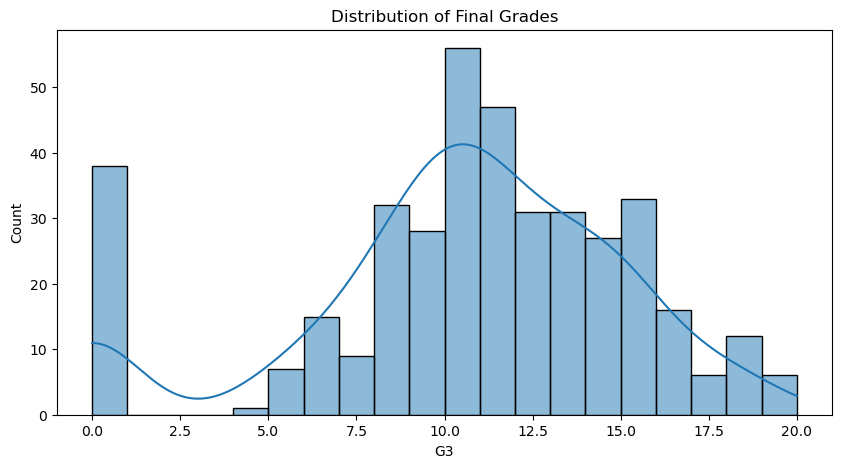

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Distribution of Final Grades")
plt.show()

# Phase 1 :  Genral Data Analysis

In [22]:
# School Analysis

df['school'].value_counts()

school
GP    349
MS     46
Name: count, dtype: int64

In [23]:
school_pct = round( df["school"].value_counts(normalize=True)*100,2)
school_pct

school
GP    88.35
MS    11.65
Name: proportion, dtype: float64

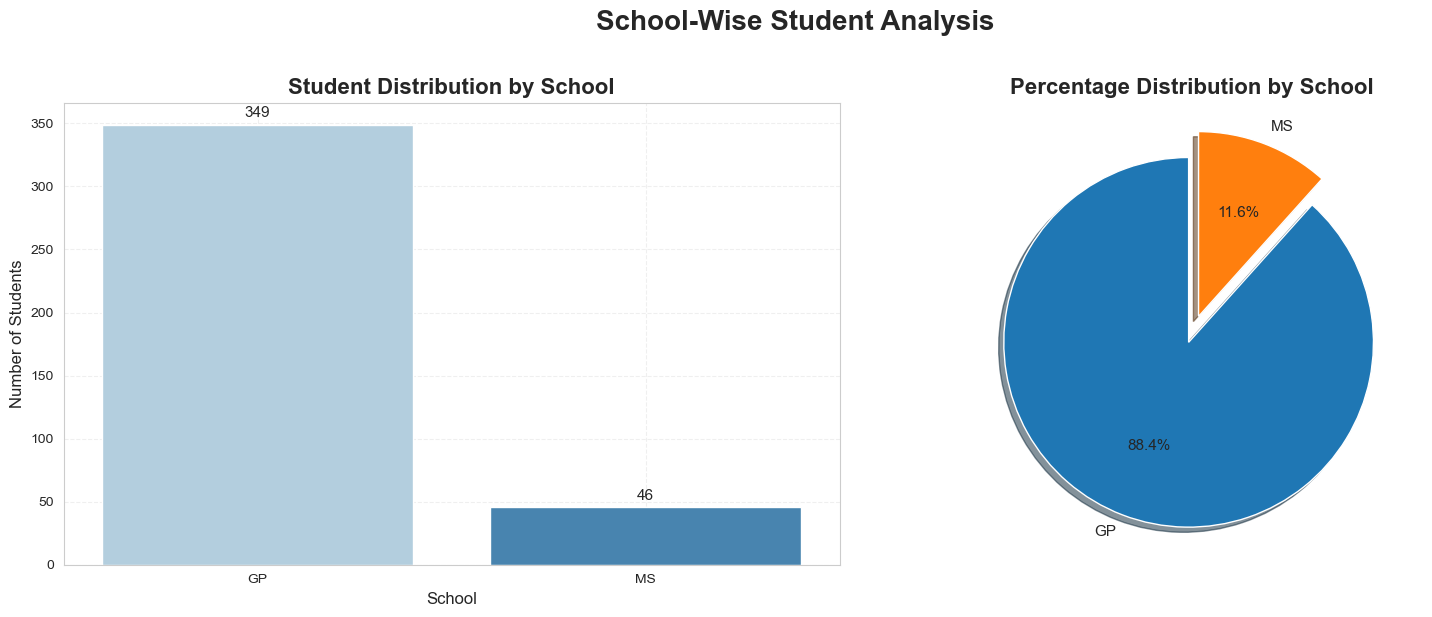

In [29]:
school_counts = df["school"].value_counts()
sns.set_style("whitegrid")
fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(16, 6))

ax1 = axes[0]
sns.countplot(
    x="school",
    hue="school",
    data=df,
    palette="Blues",
    legend=False,
    ax=ax1
)
ax1.set_title("Student Distribution by School",fontsize=16,fontweight='bold')
ax1.set_xlabel("School", fontsize=12)
ax1.set_ylabel("Number of Students", fontsize=12)

for container in ax1.containers:ax1.bar_label(container,fontsize=11,padding=3)

ax1.grid(alpha=0.3,linestyle='--')

# Pie Chart

ax2 = axes[1]
ax2.pie(school_counts,labels=school_counts.index,autopct='%1.1f%%',startangle=90,explode=[0.05, 0.1],shadow=True,textprops={'fontsize': 11})
ax2.set_title("Percentage Distribution by School",fontsize=16,fontweight='bold')

fig.suptitle("School-Wise Student Analysis",fontsize=20,fontweight='bold',y=1.02)

plt.tight_layout()
plt.show()

In [30]:
study_counts = df["studytime"].value_counts().sort_index()

study_counts

studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64

In [33]:
study_labels = {
    1: "<2 hrs",
    2: "2-5 hrs",
    3: "5-10 hrs",
    4: ">10 hrs"
}

df["studytime_label"] = df["studytime"].map(study_labels)
df["studytime_label"].head().reset_index()

,index,studytime_label
0,0,2-5 hrs
1,1,2-5 hrs
2,2,2-5 hrs
3,3,5-10 hrs
4,4,2-5 hrs


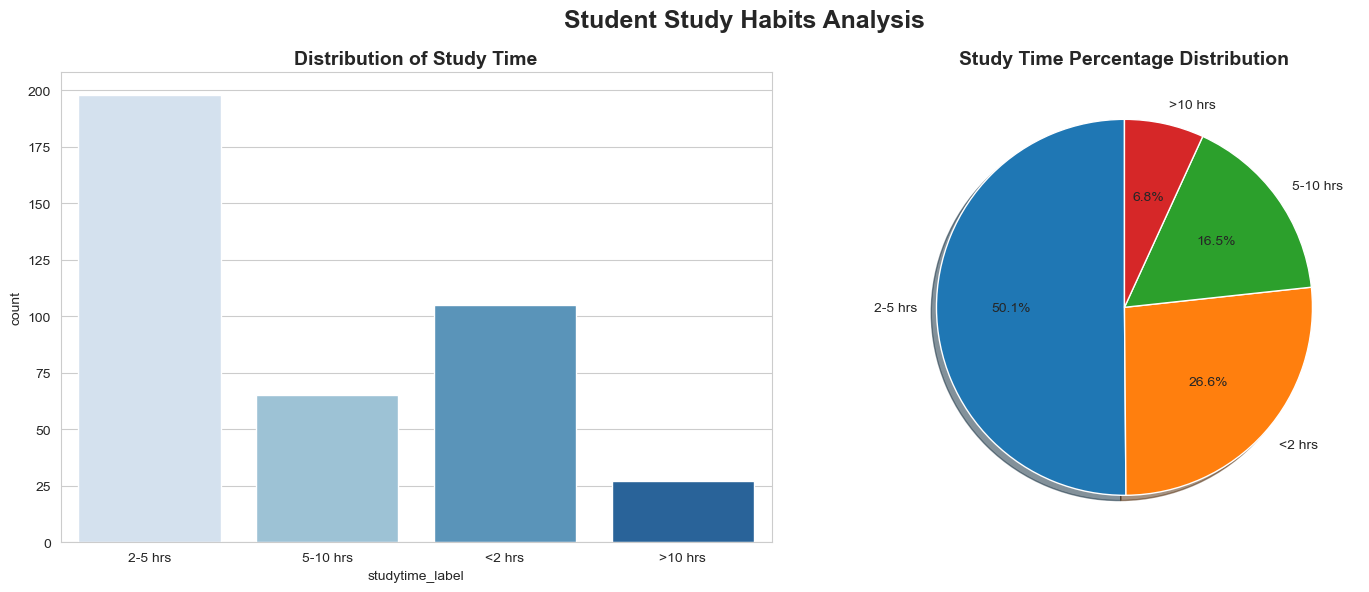

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Count Plot
sns.countplot(
    x="studytime_label",
    hue="studytime_label",
    data=df,
    palette="Blues",
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Distribution of Study Time",
    fontsize=14,
    fontweight="bold"
)

# Pie Chart
study_counts = df["studytime_label"].value_counts()

axes[1].pie(
    study_counts,
    labels=study_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)

axes[1].set_title(
    "Study Time Percentage Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.suptitle(
    "Student Study Habits Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

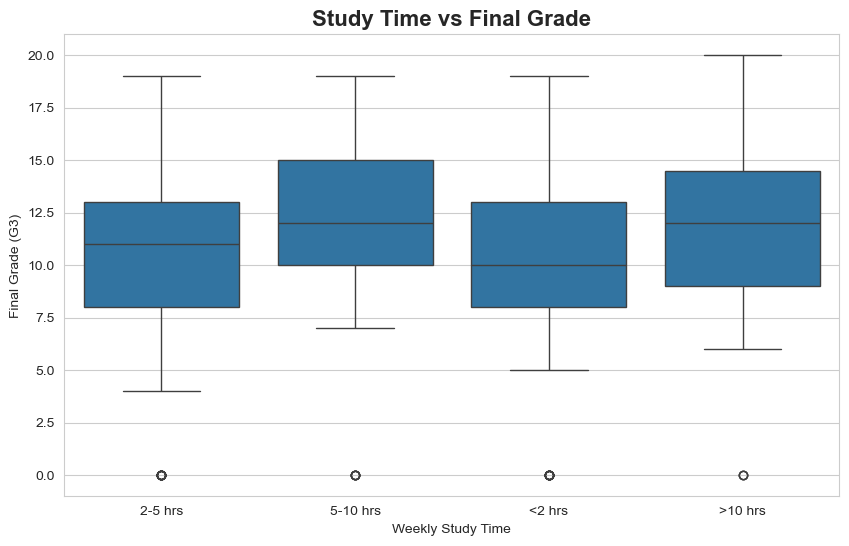

In [35]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="studytime_label",
    y="G3",
    data=df
)

plt.title(
    "Study Time vs Final Grade",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Weekly Study Time")
plt.ylabel("Final Grade (G3)")

plt.show()

In [36]:
study_summary = (
    df.groupby("studytime_label")["G3"]
      .agg([
          "count",
          "mean",
          "median",
          "min",
          "max",
          "std"
      ])
      .round(2)
)

study_summary

,count,mean,median,min,max,std
studytime_label,,,,,,
2-5 hrs,198,10.17,11.0,0,19,4.22
5-10 hrs,65,11.40,12.0,0,19,4.64
<2 hrs,105,10.05,10.0,0,19,4.96
>10 hrs,27,11.26,12.0,0,20,5.28


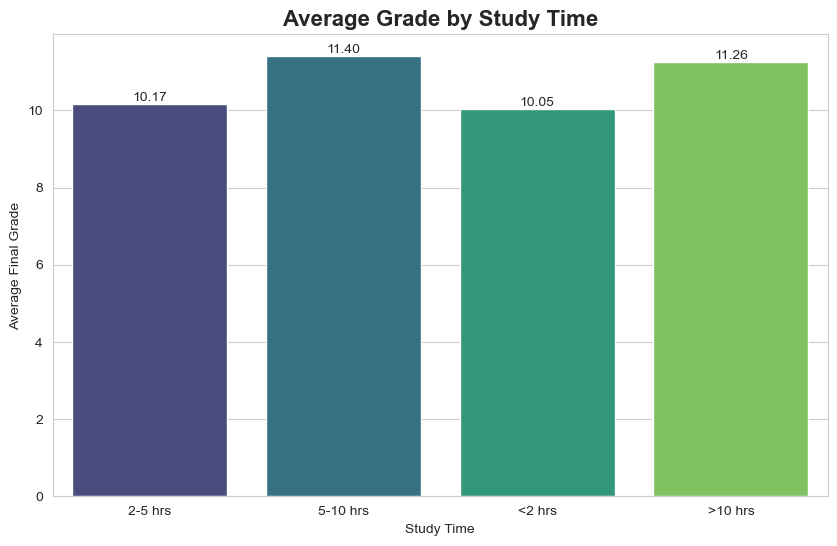

In [37]:
avg_grades = (
    df.groupby("studytime_label")["G3"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=avg_grades,
    x="studytime_label",
    y="G3",
    hue="studytime_label",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title(
    "Average Grade by Study Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Study Time")
plt.ylabel("Average Final Grade")

plt.show()

In [38]:
df[["studytime", "G3"]].corr()

,studytime,G3
studytime,1.00000,0.09782
G3,0.09782,1.00000
